
# Добровольский А.В. ИУ5-23М
## Лабораторная работа №2

### Масштабирование признаков, обработка выбросов, нестандартные признаки и отбор признаков

В этой лабораторной работе используются **другие датасеты**, не те, что были в предыдущем примере:

1. **Wine recognition dataset** из `sklearn.datasets` — основной датасет для масштабирования, обработки выбросов и отбора признаков.
2. **Digits dataset** из `sklearn.datasets` — дополнительный датасет для обработки нестандартного признака: изображения цифр размером 8×8.

Оба датасета встроены в `scikit-learn`


In [1]:
!pip install matplotlib

  Using cached contourpy-1.3.3-cp314-cp314-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.62.1-cp314-cp314-win_amd64.whl.metadata (119 kB)
  Using cached kiwisolver-1.5.0-cp314-cp314-win_amd64.whl.metadata (5.2 kB)
  Using cached pillow-12.2.0-cp314-cp314-win_amd64.whl.metadata (9.0 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   --- ------------------------------------ 0.8/8.3 MB 7.9 MB/s eta 0:00:01
   ------------------------------- -------- 6.6/8.3 MB 20.9 MB/s eta 0:00:01
   ---------------------------------------- 8.3/8.3 MB 21.5 MB/s  0:00:00
Using cached contourpy-1.3.3-cp314-cp314-win_amd64.whl (232 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.62.1-cp314-cp314-win_amd64.whl (2.3 MB)
Using cached kiwisolver-1.5.0-cp314-cp314-win_amd64.whl (75 kB)
Using cached pillow-12.2.0-c


## 1. Подключение библиотек


In [2]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine, load_digits
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.feature_selection import SelectKBest, f_classif, RFE, SelectFromModel
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

pd.set_option('display.max_columns', 100)
RANDOM_STATE = 42



## 2. Загрузка основного датасета Wine

Датасет `Wine` содержит результаты химического анализа вин.  
Целевая переменная — класс вина. Признаки числовые, поэтому датасет хорошо подходит для:

- масштабирования признаков;
- поиска и обработки выбросов;
- отбора признаков разными методами.


In [3]:

wine = load_wine()

X = pd.DataFrame(wine.data, columns=wine.feature_names)
y = pd.Series(wine.target, name='target')

df = X.copy()
df['target'] = y

print('Размер датасета:', df.shape)
print('Классы:', wine.target_names)
df.head()


Размер датасета: (178, 14)
Классы: ['class_0' 'class_1' 'class_2']


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [5]:

# Общая информация о признаках
print('Количество признаков:', X.shape[1])
print('Количество объектов:', X.shape[0])
print('\nТипы данных:')
print(df.dtypes)

print('\nКоличество объектов по классам:')
print(df['target'].value_counts().sort_index())


Количество признаков: 13
Количество объектов: 178

Типы данных:
alcohol                         float64
malic_acid                      float64
ash                             float64
alcalinity_of_ash               float64
magnesium                       float64
total_phenols                   float64
flavanoids                      float64
nonflavanoid_phenols            float64
proanthocyanins                 float64
color_intensity                 float64
hue                             float64
od280/od315_of_diluted_wines    float64
proline                         float64
target                            int64
dtype: object

Количество объектов по классам:
target
0    59
1    71
2    48
Name: count, dtype: int64



## 3. Масштабирование признаков тремя способами

Выполним масштабирование признаков тремя способами:

1. `StandardScaler` — стандартизация: среднее значение около 0, стандартное отклонение около 1.
2. `MinMaxScaler` — приведение значений к диапазону от 0 до 1.
3. `RobustScaler` — масштабирование с использованием медианы и межквартильного размаха, более устойчивое к выбросам.


In [6]:

standard_scaler = StandardScaler()
minmax_scaler = MinMaxScaler()
robust_scaler = RobustScaler()

X_standard = pd.DataFrame(
    standard_scaler.fit_transform(X),
    columns=X.columns
)

X_minmax = pd.DataFrame(
    minmax_scaler.fit_transform(X),
    columns=X.columns
)

X_robust = pd.DataFrame(
    robust_scaler.fit_transform(X),
    columns=X.columns
)

print('StandardScaler:')
display(X_standard.head())

print('MinMaxScaler:')
display(X_minmax.head())

print('RobustScaler:')
display(X_robust.head())


StandardScaler:


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,1.518613,-0.562250,0.232053,-1.169593,1.913905,0.808997,1.034819,-0.659563,1.224884,0.251717,0.362177,1.847920,1.013009
1,0.246290,-0.499413,-0.827996,-2.490847,0.018145,0.568648,0.733629,-0.820719,-0.544721,-0.293321,0.406051,1.113449,0.965242
2,0.196879,0.021231,1.109334,-0.268738,0.088358,0.808997,1.215533,-0.498407,2.135968,0.269020,0.318304,0.788587,1.395148
3,1.691550,-0.346811,0.487926,-0.809251,0.930918,2.491446,1.466525,-0.981875,1.032155,1.186068,-0.427544,1.184071,2.334574
4,0.295700,0.227694,1.840403,0.451946,1.281985,0.808997,0.663351,0.226796,0.401404,-0.319276,0.362177,0.449601,-0.037874


MinMaxScaler:


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,0.842105,0.191700,0.572193,0.257732,0.619565,0.627586,0.573840,0.283019,0.593060,0.372014,0.455285,0.970696,0.561341
1,0.571053,0.205534,0.417112,0.030928,0.326087,0.575862,0.510549,0.245283,0.274448,0.264505,0.463415,0.780220,0.550642
2,0.560526,0.320158,0.700535,0.412371,0.336957,0.627586,0.611814,0.320755,0.757098,0.375427,0.447154,0.695971,0.646933
3,0.878947,0.239130,0.609626,0.319588,0.467391,0.989655,0.664557,0.207547,0.558360,0.556314,0.308943,0.798535,0.857347
4,0.581579,0.365613,0.807487,0.536082,0.521739,0.627586,0.495781,0.490566,0.444795,0.259386,0.455285,0.608059,0.325963


RobustScaler:


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,0.897338,-0.104730,0.201439,-0.906977,1.526316,0.420804,0.553892,-0.358209,1.050000,0.318792,0.222222,0.924949,0.808050
1,0.114068,-0.057432,-0.633094,-1.930233,0.105263,0.278960,0.374251,-0.477612,-0.392857,-0.104027,0.251852,0.503043,0.777090
2,0.083650,0.334459,0.892086,-0.209302,0.157895,0.420804,0.661677,-0.238806,1.792857,0.332215,0.192593,0.316430,1.055728
3,1.003802,0.057432,0.402878,-0.627907,0.789474,1.413712,0.811377,-0.597015,0.892857,1.043624,-0.311111,0.543611,1.664603
4,0.144487,0.489865,1.467626,0.348837,1.052632,0.420804,0.332335,0.298507,0.378571,-0.124161,0.222222,0.121704,0.126935


In [7]:

comparison = pd.DataFrame({
    'original_mean': X.mean(),
    'standard_mean': X_standard.mean(),
    'standard_std': X_standard.std(),
    'minmax_min': X_minmax.min(),
    'minmax_max': X_minmax.max(),
    'robust_median': X_robust.median()
})

comparison.round(3)


,original_mean,standard_mean,standard_std,minmax_min,minmax_max,robust_median
alcohol,13.001,-0.0,1.003,0.0,1.0,0.0
malic_acid,2.336,-0.0,1.003,0.0,1.0,-0.0
ash,2.367,-0.0,1.003,0.0,1.0,0.0
alcalinity_of_ash,19.495,-0.0,1.003,0.0,1.0,0.0
magnesium,99.742,-0.0,1.003,0.0,1.0,0.0
total_phenols,2.295,0.0,1.003,0.0,1.0,0.0
flavanoids,2.029,-0.0,1.003,0.0,1.0,0.0
nonflavanoid_phenols,0.362,0.0,1.003,0.0,1.0,0.0
proanthocyanins,1.591,-0.0,1.003,0.0,1.0,-0.0
color_intensity,5.058,0.0,1.003,0.0,1.0,0.0



### Вывод по масштабированию

- После `StandardScaler` средние значения признаков становятся близки к 0.
- После `MinMaxScaler` все признаки находятся в диапазоне от 0 до 1.
- После `RobustScaler` медиана признаков становится близка к 0 - удобен при наличии выбросов.



## 4. Обработка выбросов для числовых признаков

Используем метод межквартильного размаха — **IQR**.

Формулы:

- `Q1` — первый квартиль;
- `Q3` — третий квартиль;
- `IQR = Q3 - Q1`;
- нижняя граница: `Q1 - 1.5 * IQR`;
- верхняя граница: `Q3 + 1.5 * IQR`.

Объекты за пределами этих границ считаем выбросами.


In [8]:

Q1 = X.quantile(0.25)
Q3 = X.quantile(0.75)
IQR = Q3 - Q1

lower_bounds = Q1 - 1.5 * IQR
upper_bounds = Q3 + 1.5 * IQR

outlier_mask = (X < lower_bounds) | (X > upper_bounds)
outlier_counts = outlier_mask.sum().sort_values(ascending=False)

print('Количество выбросов по признакам:')
outlier_counts


Количество выбросов по признакам:


magnesium                       4
alcalinity_of_ash               4
color_intensity                 4
malic_acid                      3
ash                             3
proanthocyanins                 2
hue                             1
alcohol                         0
total_phenols                   0
nonflavanoid_phenols            0
flavanoids                      0
od280/od315_of_diluted_wines    0
proline                         0
dtype: int64


### 4.1. Удаление выбросов

Первый способ обработки выбросов — удалить строки, в которых хотя бы один числовой признак выходит за границы IQR.


In [9]:

# Строка считается выбросом, если хотя бы один признак находится вне допустимых границ
rows_with_outliers = outlier_mask.any(axis=1)

X_removed = X.loc[~rows_with_outliers].copy()
y_removed = y.loc[~rows_with_outliers].copy()

print('Размер до удаления выбросов:', X.shape)
print('Размер после удаления выбросов:', X_removed.shape)
print('Удалено строк:', X.shape[0] - X_removed.shape[0])


Размер до удаления выбросов: (178, 13)
Размер после удаления выбросов: (161, 13)
Удалено строк: 17



### 4.2. Замена выбросов

Второй способ обработки выбросов — не удалять строки, а заменить слишком маленькие и слишком большие значения на допустимые границы.  


In [10]:

X_clipped = X.clip(lower=lower_bounds, upper=upper_bounds, axis=1)

changed_values_count = (X != X_clipped).sum().sum()
print('Количество заменённых значений:', changed_values_count)

# Проверка
outlier_mask_after = (X_clipped < lower_bounds) | (X_clipped > upper_bounds)
print('Количество выбросов после замены:', outlier_mask_after.sum().sum())

X_clipped.head()


Количество заменённых значений: 21
Количество выбросов после замены: 0


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0



## 5. Обработка нестандартного признака

В качестве нестандартного признака используем изображения из датасета `Digits`.  
Каждый объект в исходном виде представлен не одной числовой колонкой и не категорией, а матрицей пикселей размером **8×8**.

Для применения классических алгоритмов машинного обучения изображение нужно преобразовать: матрицу 8×8 можно развернуть в вектор из 64 числовых признаков.


In [11]:

digits = load_digits()

images = digits.images
digits_target = digits.target

print('Форма массива изображений:', images.shape)
print('Форма одного изображения:', images[0].shape)
print('Целевая метка первого изображения:', digits_target[0])


Форма массива изображений: (1797, 8, 8)
Форма одного изображения: (8, 8)
Целевая метка первого изображения: 0


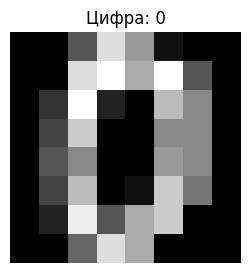

In [12]:

plt.figure(figsize=(3, 3))
plt.imshow(images[0], cmap='gray')
plt.title(f'Цифра: {digits_target[0]}')
plt.axis('off')
plt.show()


In [13]:

# Преобразование нестандартного признака: изображение 8x8 -> вектор из 64 числовых признаков
X_digits_flat = images.reshape(images.shape[0], -1)

# Нормализуем значения пикселей: в датасете они находятся в диапазоне 0..16
X_digits_scaled = X_digits_flat / 16.0

pixel_columns = [f'pixel_{i}' for i in range(X_digits_scaled.shape[1])]
digits_df = pd.DataFrame(X_digits_scaled, columns=pixel_columns)
digits_df['target'] = digits_target

print('Размер после преобразования изображений:', digits_df.shape)
digits_df.head()


Размер после преобразования изображений: (1797, 65)


,pixel_0,pixel_1,pixel_2,pixel_3,pixel_4,pixel_5,pixel_6,pixel_7,pixel_8,pixel_9,pixel_10,pixel_11,pixel_12,pixel_13,pixel_14,pixel_15,pixel_16,pixel_17,pixel_18,pixel_19,pixel_20,pixel_21,pixel_22,pixel_23,pixel_24,pixel_25,pixel_26,pixel_27,pixel_28,pixel_29,pixel_30,pixel_31,pixel_32,pixel_33,pixel_34,pixel_35,pixel_36,pixel_37,pixel_38,pixel_39,pixel_40,pixel_41,pixel_42,pixel_43,pixel_44,pixel_45,pixel_46,pixel_47,pixel_48,pixel_49,pixel_50,pixel_51,pixel_52,pixel_53,pixel_54,pixel_55,pixel_56,pixel_57,pixel_58,pixel_59,pixel_60,pixel_61,pixel_62,pixel_63,target
0,0.0,0.0,0.3125,0.8125,0.5625,0.0625,0.0,0.0,0.0,0.0,0.8125,0.9375,0.6250,0.9375,0.3125,0.0,0.0,0.1875,0.9375,0.1250,0.0000,0.6875,0.500,0.0,0.0,0.2500,0.7500,0.0000,0.0000,0.5000,0.5,0.0,0.0,0.3125,0.5000,0.0000,0.0000,0.5625,0.5000,0.0,0.0,0.2500,0.6875,0.0,0.0625,0.750,0.4375,0.0,0.0,0.1250,0.8750,0.3125,0.6250,0.7500,0.0000,0.0,0.0,0.0,0.3750,0.8125,0.6250,0.0000,0.0000,0.0,0
1,0.0,0.0,0.0000,0.7500,0.8125,0.3125,0.0,0.0,0.0,0.0,0.0000,0.6875,1.0000,0.5625,0.0000,0.0,0.0,0.0000,0.1875,0.9375,1.0000,0.3750,0.000,0.0,0.0,0.4375,0.9375,1.0000,1.0000,0.1250,0.0,0.0,0.0,0.0000,0.0625,1.0000,1.0000,0.1875,0.0000,0.0,0.0,0.0000,0.0625,1.0,1.0000,0.375,0.0000,0.0,0.0,0.0000,0.0625,1.0000,1.0000,0.3750,0.0000,0.0,0.0,0.0,0.0000,0.6875,1.0000,0.6250,0.0000,0.0,1
2,0.0,0.0,0.0000,0.2500,0.9375,0.7500,0.0,0.0,0.0,0.0,0.1875,1.0000,0.9375,0.8750,0.0000,0.0,0.0,0.0000,0.5000,0.8125,0.5000,1.0000,0.000,0.0,0.0,0.0000,0.0625,0.3750,0.9375,0.6875,0.0,0.0,0.0,0.0625,0.5000,0.8125,0.9375,0.0625,0.0000,0.0,0.0,0.5625,1.0000,1.0,0.3125,0.000,0.0000,0.0,0.0,0.1875,0.8125,1.0000,1.0000,0.6875,0.3125,0.0,0.0,0.0,0.0000,0.1875,0.6875,1.0000,0.5625,0.0,2
3,0.0,0.0,0.4375,0.9375,0.8125,0.0625,0.0,0.0,0.0,0.5,0.8125,0.3750,0.9375,0.2500,0.0000,0.0,0.0,0.1250,0.0625,0.8125,0.8125,0.0000,0.000,0.0,0.0,0.0000,0.1250,0.9375,0.6875,0.0625,0.0,0.0,0.0,0.0000,0.0000,0.0625,0.7500,0.7500,0.0625,0.0,0.0,0.0000,0.0000,0.0,0.0625,0.625,0.5000,0.0,0.0,0.0000,0.5000,0.2500,0.3125,0.8750,0.5625,0.0,0.0,0.0,0.4375,0.8125,0.8125,0.5625,0.0000,0.0,3
4,0.0,0.0,0.0000,0.0625,0.6875,0.0000,0.0,0.0,0.0,0.0,0.0000,0.4375,0.5000,0.0000,0.0000,0.0,0.0,0.0000,0.0625,0.8125,0.3750,0.1250,0.125,0.0,0.0,0.0000,0.4375,0.9375,0.0000,0.5625,0.5,0.0,0.0,0.3125,1.0000,0.6250,0.0000,1.0000,0.3750,0.0,0.0,0.2500,0.9375,1.0,0.8125,1.000,0.0625,0.0,0.0,0.0000,0.0000,0.1875,0.9375,0.6250,0.0000,0.0,0.0,0.0,0.0000,0.1250,1.0000,0.2500,0.0000,0.0,4



### Вывод по нестандартному признаку

Изображение как объект не является обычным числовым или категориальным признаком.  
Мы преобразовали изображение 8×8 в 64 числовых признака — значения пикселей. После такого преобразования данные можно использовать в обычных моделях машинного обучения.



## 6. Отбор признаков

Выполним отбор признаков на датасете `Wine` тремя группами методов:

1. **Filter methods** — фильтрация признаков на основе статистического критерия.
2. **Wrapper methods** — подбор признаков с учётом качества конкретной модели.
3. **Embedded methods** — отбор признаков встроен в процесс обучения модели.

Для сравнения будем выбирать по 5 признаков.


In [14]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=RANDOM_STATE,
    stratify=y
)

# Для LogisticRegression признаки лучше стандартизировать
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X.columns,
    index=X_train.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X.columns,
    index=X_test.index
)

print('Размер обучающей выборки:', X_train_scaled.shape)
print('Размер тестовой выборки:', X_test_scaled.shape)


Размер обучающей выборки: (124, 13)
Размер тестовой выборки: (54, 13)


In [15]:

def evaluate_selected_features(selected_features, model=None):
    # Обучает модель только на выбранных признаках и возвращает accuracy.
    if model is None:
        model = LogisticRegression(max_iter=10000, random_state=RANDOM_STATE)
    
    model.fit(X_train_scaled[selected_features], y_train)
    predictions = model.predict(X_test_scaled[selected_features])
    return accuracy_score(y_test, predictions)



### 6.1. Filter method: SelectKBest

Метод `SelectKBest` выбирает признаки, которые имеют наилучшие значения статистического критерия.  
Так как задача классификации, используем критерий `f_classif`.


In [16]:

filter_selector = SelectKBest(score_func=f_classif, k=5)
filter_selector.fit(X_train_scaled, y_train)

filter_features = X.columns[filter_selector.get_support()].tolist()
filter_scores = pd.DataFrame({
    'feature': X.columns,
    'score': filter_selector.scores_
}).sort_values(by='score', ascending=False)

filter_accuracy = evaluate_selected_features(filter_features)

print('Выбранные признаки методом фильтрации:')
print(filter_features)
print('Accuracy:', round(filter_accuracy, 4))

filter_scores.head(10)


Выбранные признаки методом фильтрации:
['alcohol', 'flavanoids', 'color_intensity', 'od280/od315_of_diluted_wines', 'proline']
Accuracy: 0.9815


,feature,score
6,flavanoids,187.685777
12,proline,149.433529
11,od280/od315_of_diluted_wines,126.619117
0,alcohol,100.346442
9,color_intensity,83.979297
10,hue,72.267297
5,total_phenols,59.255803
3,alcalinity_of_ash,26.052781
1,malic_acid,22.582802
8,proanthocyanins,19.979866



### 6.2. Wrapper method: RFE

Метод `RFE` — Recursive Feature Elimination.  
Он обучает модель, оценивает важность признаков и постепенно удаляет наименее значимые признаки.


In [17]:

wrapper_estimator = LogisticRegression(max_iter=10000, random_state=RANDOM_STATE)

rfe_selector = RFE(
    estimator=wrapper_estimator,
    n_features_to_select=5
)
rfe_selector.fit(X_train_scaled, y_train)

wrapper_features = X.columns[rfe_selector.get_support()].tolist()
wrapper_ranking = pd.DataFrame({
    'feature': X.columns,
    'ranking': rfe_selector.ranking_
}).sort_values(by='ranking')

wrapper_accuracy = evaluate_selected_features(wrapper_features)

print('Выбранные признаки методом обёртывания RFE:')
print(wrapper_features)
print('Accuracy:', round(wrapper_accuracy, 4))

wrapper_ranking


Выбранные признаки методом обёртывания RFE:
['alcohol', 'flavanoids', 'color_intensity', 'hue', 'proline']
Accuracy: 0.9815


,feature,ranking
0,alcohol,1
6,flavanoids,1
10,hue,1
9,color_intensity,1
12,proline,1
11,od280/od315_of_diluted_wines,2
2,ash,3
3,alcalinity_of_ash,4
8,proanthocyanins,5
1,malic_acid,6



### 6.3. Embedded method: SelectFromModel на основе RandomForestClassifier

Встроенные методы выполняют отбор признаков в процессе обучения модели.  
В данном примере используем `RandomForestClassifier`, который рассчитывает важность признаков.


In [ ]:

forest = RandomForestClassifier(
    n_estimators=300,
    random_state=RANDOM_STATE
)

embedded_selector = SelectFromModel(
    estimator=forest,
    threshold=-np.inf,
    max_features=5
)
embedded_selector.fit(X_train, y_train)

embedded_features = X.columns[embedded_selector.get_support()].tolist()

embedded_accuracy = evaluate_selected_features(embedded_features)

importances = embedded_selector.estimator_.feature_importances_
importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance': importances
}).sort_values(by='importance', ascending=False)

print('Выбранные признаки embedded-методом:')
print(embedded_features)
print('Accuracy:', round(embedded_accuracy, 4))

importance_df.head(10)


Выбранные признаки embedded-методом:
['alcohol', 'flavanoids', 'color_intensity', 'hue', 'proline']
Accuracy: 0.9815


,feature,importance
9,color_intensity,0.158937
6,flavanoids,0.153765
12,proline,0.152451
0,alcohol,0.143471
10,hue,0.096152
11,od280/od315_of_diluted_wines,0.091101
5,total_phenols,0.057045
1,malic_acid,0.034370
4,magnesium,0.031814
3,alcalinity_of_ash,0.031144



## 7. Сравнение выбранных признаков


In [19]:

selection_summary = pd.DataFrame({
    'method': ['Filter: SelectKBest', 'Wrapper: RFE', 'Embedded: RandomForest'],
    'selected_features': [filter_features, wrapper_features, embedded_features],
    'accuracy': [filter_accuracy, wrapper_accuracy, embedded_accuracy]
})

selection_summary


,method,selected_features,accuracy
0,Filter: SelectKBest,"[alcohol, flavanoids, color_intensity, od280/o...",0.981481
1,Wrapper: RFE,"[alcohol, flavanoids, color_intensity, hue, pr...",0.981481
2,Embedded: RandomForest,"[alcohol, flavanoids, color_intensity, hue, pr...",0.981481
